# RepCounting

Two rep-counting methods on the **`philosopher0808/gym-workoutexercises-video`** dataset:

1. **Angle-based counter** —
   feeding a per-exercise two-state machine with thresholds determining reps.

2. **PCA-based counter** — identical to `PCARepCounter.ipynb`: a 12-dim per-frame feature
   vector → `StandardScaler` + `PCA`, project to the most periodic PC, SavGol-smooth a
   rolling buffer, amplitude guard, adaptive mean±0.8σ Schmitt.

In [ ]:
!pip install -q mediapipe opencv-python-headless kagglehub tqdm scikit-learn scipy
print("Packages installed (DTW / tslearn / coremltools / opendatasets removed)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.2 MB/s eta 0:00:00
Packages installed (DTW / tslearn / coremltools / opendatasets removed)


In [ ]:
import os, cv2, base64, urllib.request, warnings, json, subprocess, random
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict, deque
from dataclasses import dataclass
from typing import List
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import HTML, display as ipy_display, clear_output

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports complete")

Imports complete


In [ ]:
PROJECT_DIR = '/content/rep_counter'
DATASET_DIR = f'{PROJECT_DIR}/datasets'
OUTPUT_DIR  = f'{PROJECT_DIR}/outputs'
for d in [PROJECT_DIR, DATASET_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)
print("Directories ready")

Directories ready


## Data — download + train/test split

Following `eda.ipynb`: download `philosopher0808/gym-workoutexercises-video`, keep only the
`verified_data` (→ **train**) and `test` (→ **test**) top-level folders, and key each video by its
parent-folder exercise name. `plank` is removed from both splits.

In [ ]:
DROP_EXERCISES = {"plank"}          # isometric — no reps
VIDEO_EXTS = (".mp4", ".mov", ".avi", ".mkv", ".webm")

path = kagglehub.dataset_download("philosopher0808/gym-workoutexercises-video")
DATASET_PATH = Path(path)
print("Dataset path:", DATASET_PATH)

train_videos = defaultdict(list)
test_videos  = defaultdict(list)

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if not file.lower().endswith(VIDEO_EXTS):
            continue
        fp = Path(root) / file
        rel = fp.relative_to(DATASET_PATH).parts
        if len(rel) < 2:
            continue
        top_level = rel[0]
        if top_level not in ("verified_data", "test"):
            continue
        exercise = rel[-2].strip()
        if exercise in DROP_EXERCISES:
            continue
        (train_videos if top_level == "verified_data" else test_videos)[exercise].append(str(fp))

exercises = sorted(set(train_videos) | set(test_videos))
print(f"\nExercises: {len(exercises)}  (plank dropped)")
print(f"{'exercise':<22}{'train':>7}{'test':>7}")
print("-" * 36)
n_train = n_test = 0
for ex in exercises:
    tr, te = len(train_videos[ex]), len(test_videos[ex])
    n_train += tr; n_test += te
    print(f"{ex:<22}{tr:>7}{te:>7}")
print("-" * 36)
print(f"{'TOTAL':<22}{n_train:>7}{n_test:>7}")

100%|██████████| 9.63G/9.63G [02:14<00:00, 77.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/philosopher0808/gym-workoutexercises-video/versions/1

Exercises: 21  (plank dropped)
exercise                train   test
------------------------------------
barbell biceps curl       111      2
bench press                94      3
chest fly machine          76      4
deadlift                   69      2
decline bench press        81      3
hammer curl                73      3
hip thrust                 56      3
incline bench press        72      3
lat pulldown               67      3
lateral raise              55      2
leg extension              58      3
leg raises                 65      3
pull Up                    61      3
push-up                    83      2
romanian deadlift          55      3
russian twist              52      3
shoulder press             37      3
squat                      87      3
t bar row                  62      3
tricep Pushdown            66      2
tricep dips                40      3
-----------------

In [ ]:
MODEL_PATH = '/content/pose_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print('Downloading pose landmarker model (~8 MB)...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/'
        'pose_landmarker_full/float16/latest/pose_landmarker_full.task',
        MODEL_PATH
    )
    print('Downloaded!')
else:
    print('Model already cached.')
print('MediaPipe ready')

Downloaded!
MediaPipe ready


## Feature extraction (PCA side — 12-dim, unchanged)

Same 12-dim feature vector as the original PCA notebook: 6 symmetry-averaged joint angles
(elbow, shoulder, hip, knee, ankle, torso) + 6 body-centre-normalised y-coords (lm 11,12,23,24,25,26).

In [ ]:
# -- Angle (2D) used for the PCA feature vector --
def calculate_angle(point_a, point_b, point_c):
    """Angle in degrees at point_b formed by vectors b->a and b->c (2D)."""
    a, b, c = np.array(point_a), np.array(point_b), np.array(point_c)
    ba, bc  = a - b, c - b
    cosine  = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))


JOINT_ANGLE_DEFINITIONS = [
    (11, 13, 15, "left_elbow"),
    (12, 14, 16, "right_elbow"),
    (13, 11, 23, "left_shoulder"),
    (14, 12, 24, "right_shoulder"),
    (11, 23, 25, "left_hip"),
    (12, 24, 26, "right_hip"),
    (23, 25, 27, "left_knee"),
    (24, 26, 28, "right_knee"),
    (25, 27, 31, "left_ankle"),
    (26, 28, 32, "right_ankle"),
    (23, 24, 12, "torso"),
]
ANGLE_NAMES = [d[3] for d in JOINT_ANGLE_DEFINITIONS]


def extract_features_from_landmarks(landmarks):
    lm = landmarks
    coords = []
    for i in range(33):
        coords.extend([lm[i].x, lm[i].y, lm[i].visibility])

    left_hip       = np.array([lm[23].x, lm[23].y])
    right_hip      = np.array([lm[24].x, lm[24].y])
    center         = (left_hip + right_hip) / 2
    left_shoulder  = np.array([lm[11].x, lm[11].y])
    right_shoulder = np.array([lm[12].x, lm[12].y])
    scale          = np.linalg.norm(left_shoulder - right_shoulder) + 1e-8

    norm_coords = []
    for i in range(33):
        norm_coords.extend([(lm[i].x - center[0]) / scale,
                             (lm[i].y - center[1]) / scale])

    angles, angle_values = [], {}
    for a_idx, b_idx, c_idx, name in JOINT_ANGLE_DEFINITIONS:
        if all(lm[i].visibility > 0.5 for i in [a_idx, b_idx, c_idx]):
            angle = calculate_angle([lm[a_idx].x, lm[a_idx].y],
                                    [lm[b_idx].x, lm[b_idx].y],
                                    [lm[c_idx].x, lm[c_idx].y])
        else:
            angle = 0.0
        angles.append(angle / 180.0)
        angle_values[name] = angle

    feature_vector = np.array(coords + norm_coords + angles, dtype=np.float32)
    feature_dict   = {
        "raw_coords":  coords,
        "norm_coords": norm_coords,
        "angles":      angle_values,
        "vector":      feature_vector,
    }
    return feature_dict, feature_vector


FEATURE_SIZE = 33*3 + 33*2 + len(JOINT_ANGLE_DEFINITIONS)
print(f"Feature extraction ready — {FEATURE_SIZE} dims")

# -- 12-dim PCA input helpers --
Y_LANDMARK_INDICES = [11, 12, 23, 24, 25, 26]

BILATERAL_PAIRS = [
    ("left_elbow",    "right_elbow"),
    ("left_shoulder", "right_shoulder"),
    ("left_hip",      "right_hip"),
    ("left_knee",     "right_knee"),
    ("left_ankle",    "right_ankle"),
]
UNILATERAL = ["torso"]
SYM_ANGLE_NAMES = ["avg_" + l.replace("left_", "") for l, _ in BILATERAL_PAIRS] + UNILATERAL
# => ["avg_elbow","avg_shoulder","avg_hip","avg_knee","avg_ankle","torso"]


def symmetry_averaged_angles(angle_dict):
    out = {}
    for l_name, r_name in BILATERAL_PAIRS:
        key = "avg_" + l_name.replace("left_", "")
        out[key] = (angle_dict.get(l_name, 0.0) + angle_dict.get(r_name, 0.0)) / 2.0
    for name in UNILATERAL:
        out[name] = angle_dict.get(name, 0.0)
    return out


def _get_feature_vec(feat_dict):
    """12-dim PCA input: 6 sym-averaged angles + 6 body-centre-normalised y-coords."""
    sym    = symmetry_averaged_angles(feat_dict["angles"])
    angles = np.array([sym[n] for n in SYM_ANGLE_NAMES], dtype=np.float32)
    nc     = feat_dict["norm_coords"]
    y_vals = np.array([nc[i * 2 + 1] for i in Y_LANDMARK_INDICES], dtype=np.float32)
    return np.concatenate([angles, y_vals])   # (12,)


print(f"PCA input: 12 dims ({len(SYM_ANGLE_NAMES)} sym-angles + {len(Y_LANDMARK_INDICES)} norm-y)")

Feature extraction ready — 176 dims
PCA input: 12 dims (6 sym-angles + 6 norm-y)


In [ ]:
def extract_angle_timeseries(video_path, max_frames=300):
    """
    Run MediaPipe on every frame.

    Returns
    -------
    angles   : dict {name: np.array}   11 raw joint angles (degrees)
    norm_y   : np.ndarray  (T, 6)      body-centre-normalised y-coords
    times    : list[float]             frame timestamps in seconds
    mean_vis : float                   mean landmark visibility (video quality proxy)
    """
    angles_buf = defaultdict(list)
    norm_y_buf = []
    times      = []
    vis_buf    = []
    cap        = cv2.VideoCapture(str(video_path))
    fps        = cap.get(cv2.CAP_PROP_FPS) or 30.0

    vid_opts = mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=mp_vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    fi = 0
    with mp_vision.PoseLandmarker.create_from_options(vid_opts) as det:
        while fi < max_frames:
            ret, frame = cap.read()
            if not ret: break
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ts  = int(fi * 1000 / fps)
            img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            res = det.detect_for_video(img, ts)
            if res.pose_landmarks:
                feat_dict, _ = extract_features_from_landmarks(res.pose_landmarks[0])
                for name, val in feat_dict["angles"].items():
                    angles_buf[name].append(val)
                nc = feat_dict["norm_coords"]
                norm_y_buf.append([nc[i * 2 + 1] for i in Y_LANDMARK_INDICES])
                times.append(fi / fps)
                vis_buf.extend(res.pose_landmarks[0][i].visibility for i in range(33))
            fi += 1

    cap.release()
    angles   = {k: np.array(v) for k, v in angles_buf.items()}
    norm_y   = (np.array(norm_y_buf, dtype=np.float32)
                if norm_y_buf else np.zeros((0, len(Y_LANDMARK_INDICES)), dtype=np.float32))
    mean_vis = float(np.mean(vis_buf)) if vis_buf else 0.0
    return angles, norm_y, times, mean_vis


print("extract_angle_timeseries ready (V3: returns mean_vis for quality filtering)")

extract_angle_timeseries ready (V3: returns mean_vis for quality filtering)


In [ ]:
def get_common_angles(video_paths, max_videos=5, **kwargs):
    """Verify that at least one video processes cleanly. Unpacks the 4-tuple."""
    for vpath in video_paths[:max_videos]:
        angles, norm_y, times, mean_vis = extract_angle_timeseries(vpath, max_frames=60)
        if times:
            return sorted(angles.keys())
    return []


def periodicity_score(signal, fps=30., min_hz=0.25, max_hz=2.5):
    """Fraction of spectral power in the rep-frequency band [0.25, 2.5] Hz."""
    n = len(signal)
    if n < 20: return 0.0
    centered = signal - signal.mean()
    power    = np.abs(np.fft.rfft(centered)) ** 2
    freqs    = np.fft.rfftfreq(n, d=1.0/fps)
    mask     = (freqs >= min_hz) & (freqs <= max_hz)
    total    = power.sum()
    return float(power[mask].sum() / (total + 1e-12))


print("Phase-1 helpers ready (get_common_angles + periodicity_score)")

Phase-1 helpers ready (get_common_angles + periodicity_score)


## Phase 1 — Build PCA profiles from 35 usable train videos

Per exercise: shuffle the train videos and extract until **35 usable** ones are collected
(≥20 detected frames and `mean_vis ≥ 0.5`), stopping early for efficiency. Fit `StandardScaler` +
`PCA` on all frames combined, then select the most periodic principal component(s) via per-video FFT
periodicity (median ≥ 0.12). No DTW / templates.

In [ ]:
@dataclass
class ExerciseProfile:
    name:          str
    angle_names:   List[str]
    scaler:        StandardScaler
    pca:           PCA
    selected_pcs:  List[int]
    pc_stats:      list
    fps:           float
    n_videos_used: int


def build_exercise_profile(exercise_name, video_paths,
                           target_usable=35,
                           max_frames=300,
                           min_visibility=0.50):
    """
    Exact V3 PCA profile logic (scaler + PCA + per-video periodicity median),
    rewired for the train/test split and the 35-random-usable-videos approach.

    `video_paths` should be pre-shuffled by the caller; this collects videos until
    `target_usable` pass the quality filter (>=20 frames, mean_vis >= min_visibility),
    stopping early. V3 DTW steps (rep segments, DBA template, DTW thresholds) are
    omitted -- PCARepCounter never uses them.
    """
    print(f"{'='*60}")
    print(f"Building profile: {exercise_name.upper()}  (target {target_usable} usable videos)")

    # 1. Extract angle + norm-y time series; visibility filter; stop at target_usable
    raw, fps_samples = [], []
    n_seen = n_skip_short = n_skip_vis = 0
    for vpath in tqdm(video_paths, desc="  Extracting", leave=False):
        if len(raw) >= target_usable:
            break
        n_seen += 1
        angles, norm_y, times, mean_vis = extract_angle_timeseries(vpath, max_frames=max_frames)
        if len(times) < 20:
            n_skip_short += 1; continue
        if mean_vis < min_visibility:
            n_skip_vis += 1; continue
        raw.append((angles, norm_y, times))
        if len(times) > 1:
            fps_samples.append(len(times) / times[-1])

    fps_est = float(np.median(fps_samples)) if fps_samples else 30.
    print(f"  Videos used: {len(raw)}  (scanned {n_seen}; skipped "
          f"{n_skip_short} short, {n_skip_vis} low-visibility)")
    if len(raw) < target_usable:
        print(f"  WARNING: only {len(raw)} usable videos (< {target_usable})")
    if not raw:
        print("  No usable videos"); return None

    print(f"  Features: 12-dim  ({len(SYM_ANGLE_NAMES)} sym-angles + {len(Y_LANDMARK_INDICES)} norm-y)")

    # 2. Build 12-dim feature matrices  (identical to V3)
    mats = []
    for angles, norm_y, times in raw:
        if not all(k in angles for k in ANGLE_NAMES): continue
        T = len(times)
        sym_block = np.zeros((T, len(SYM_ANGLE_NAMES)), dtype=np.float32)
        for t in range(T):
            frame_angles = {n: float(angles[n][t]) for n in ANGLE_NAMES}
            sym = symmetry_averaged_angles(frame_angles)
            sym_block[t] = [sym[n] for n in SYM_ANGLE_NAMES]
        mats.append(np.hstack([sym_block, norm_y]))   # (T, 12)

    if not mats:
        print("  No matrices built"); return None

    # 3. Fit scaler + PCA on ALL videos combined  (identical to V3)
    combined = np.vstack(mats)
    scaler   = StandardScaler().fit(combined)
    c_scaled = scaler.transform(combined)

    n_comp = min(combined.shape[1], 8)
    pca    = PCA(n_components=n_comp).fit(c_scaled)

    # 4. Project each video; score periodicity PER VIDEO -> median  (identical to V3)
    per_video_proj = [pca.transform(scaler.transform(m)) for m in mats]

    pc_stats, selected_pcs = [], []
    for i in range(n_comp):
        var = float(pca.explained_variance_ratio_[i])
        if var < 0.03: break
        per_vid_scores = [periodicity_score(proj[:, i], fps=fps_est) for proj in per_video_proj]
        score = float(np.median(per_vid_scores))
        pc_stats.append((i, var, score))
        tag = "selected" if score >= 0.12 else "(skipped)"
        print(f"  PC{i+1}: var={var:.2%}  periodicity(median)={score:.2f}  {tag}")
        if score >= 0.12:
            selected_pcs.append(i)

    if not selected_pcs:
        selected_pcs = [0]
        print("  No periodic PCs - falling back to PC1")

    return ExerciseProfile(
        name=exercise_name, angle_names=SYM_ANGLE_NAMES,
        scaler=scaler, pca=pca,
        selected_pcs=selected_pcs, pc_stats=pc_stats,
        fps=fps_est, n_videos_used=len(mats),
    )


print("ExerciseProfile + build_exercise_profile ready (V3 PCA logic, 35 usable, no DTW)")

ExerciseProfile + build_exercise_profile ready (V3 PCA logic, 35 usable, no DTW)


In [ ]:
print("Scanning exercises...")
exercise_angle_map = {}
for exercise, vpaths in sorted(train_videos.items()):
    common = get_common_angles(vpaths, max_videos=5)
    exercise_angle_map[exercise] = common
    print(f"  {exercise}: {len(common)} angles detected")

N_PROFILE_VIDEOS = 35
exercise_profiles = {}
for exercise, vpaths in sorted(train_videos.items()):
    paths = list(vpaths)
    random.shuffle(paths)                      # 35 RANDOM train videos
    profile = build_exercise_profile(
        exercise, paths,
        target_usable=N_PROFILE_VIDEOS,
        min_visibility=0.50,
    )
    if profile is not None:
        exercise_profiles[exercise] = profile

print(f"\nProfiles built: {list(exercise_profiles.keys())}")
for ex, prof in exercise_profiles.items():
    print(f"  {ex}: {prof.n_videos_used} videos | {len(prof.selected_pcs)} PCs")

Scanning exercises...
  barbell biceps curl: 11 angles detected
  bench press: 11 angles detected
  chest fly machine: 11 angles detected
  deadlift: 11 angles detected
  decline bench press: 11 angles detected
  hammer curl: 11 angles detected
  hip thrust: 11 angles detected
  incline bench press: 11 angles detected
  lat pulldown: 11 angles detected
  lateral raise: 11 angles detected
  leg extension: 11 angles detected
  leg raises: 11 angles detected
  pull Up: 11 angles detected
  push-up: 11 angles detected
  romanian deadlift: 11 angles detected
  russian twist: 11 angles detected
  shoulder press: 11 angles detected
  squat: 11 angles detected
  t bar row: 11 angles detected
  tricep Pushdown: 11 angles detected
  tricep dips: 11 angles detected
Building profile: BARBELL BICEPS CURL  (target 35 usable videos)


  Videos used: 35  (scanned 36; skipped 1 short, 0 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=35.71%  periodicity(median)=0.73  selected
  PC2: var=21.72%  periodicity(median)=0.76  selected
  PC3: var=16.86%  periodicity(median)=0.76  selected
  PC4: var=8.05%  periodicity(median)=0.79  selected
  PC5: var=7.81%  periodicity(median)=0.88  selected
  PC6: var=5.04%  periodicity(median)=0.78  selected
  PC7: var=3.41%  periodicity(median)=0.67  selected
Building profile: BENCH PRESS  (target 35 usable videos)


  Videos used: 35  (scanned 37; skipped 1 short, 1 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=26.14%  periodicity(median)=0.65  selected
  PC2: var=17.05%  periodicity(median)=0.62  selected
  PC3: var=15.93%  periodicity(median)=0.68  selected
  PC4: var=12.78%  periodicity(median)=0.59  selected
  PC5: var=10.93%  periodicity(median)=0.73  selected
  PC6: var=7.50%  periodicity(median)=0.56  selected
  PC7: var=5.90%  periodicity(median)=0.67  selected
Building profile: CHEST FLY MACHINE  (target 35 usable videos)


  Videos used: 35  (scanned 35; skipped 0 short, 0 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=49.57%  periodicity(median)=0.70  selected
  PC2: var=21.25%  periodicity(median)=0.57  selected
  PC3: var=11.97%  periodicity(median)=0.56  selected
  PC4: var=7.04%  periodicity(median)=0.62  selected
  PC5: var=5.34%  periodicity(median)=0.59  selected
  PC6: var=3.86%  periodicity(median)=0.60  selected
Building profile: DEADLIFT  (target 35 usable videos)


  Videos used: 35  (scanned 35; skipped 0 short, 0 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=39.76%  periodicity(median)=0.59  selected
  PC2: var=20.77%  periodicity(median)=0.57  selected
  PC3: var=18.44%  periodicity(median)=0.64  selected
  PC4: var=9.96%  periodicity(median)=0.68  selected
  PC5: var=5.61%  periodicity(median)=0.60  selected
Building profile: DECLINE BENCH PRESS  (target 35 usable videos)


...

  Videos used: 35  (scanned 35; skipped 0 short, 0 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=39.24%  periodicity(median)=0.65  selected
  PC2: var=20.54%  periodicity(median)=0.69  selected
  PC3: var=14.85%  periodicity(median)=0.90  selected
  PC4: var=10.00%  periodicity(median)=0.68  selected
  PC5: var=7.53%  periodicity(median)=0.73  selected
  PC6: var=4.13%  periodicity(median)=0.82  selected
Building profile: SQUAT  (target 35 usable videos)


  Videos used: 35  (scanned 35; skipped 0 short, 0 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=32.62%  periodicity(median)=0.56  selected
  PC2: var=22.00%  periodicity(median)=0.62  selected
  PC3: var=20.06%  periodicity(median)=0.72  selected
  PC4: var=10.30%  periodicity(median)=0.62  selected
  PC5: var=5.34%  periodicity(median)=0.69  selected
  PC6: var=4.37%  periodicity(median)=0.78  selected
  PC7: var=3.56%  periodicity(median)=0.63  selected
Building profile: T BAR ROW  (target 35 usable videos)


  Videos used: 35  (scanned 35; skipped 0 short, 0 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=44.39%  periodicity(median)=0.68  selected
  PC2: var=22.85%  periodicity(median)=0.60  selected
  PC3: var=12.62%  periodicity(median)=0.62  selected
  PC4: var=10.31%  periodicity(median)=0.64  selected
  PC5: var=4.81%  periodicity(median)=0.70  selected
Building profile: TRICEP PUSHDOWN  (target 35 usable videos)


  Videos used: 35  (scanned 35; skipped 0 short, 0 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=36.56%  periodicity(median)=0.74  selected
  PC2: var=21.76%  periodicity(median)=0.77  selected
  PC3: var=19.10%  periodicity(median)=0.72  selected
  PC4: var=8.74%  periodicity(median)=0.86  selected
  PC5: var=6.92%  periodicity(median)=0.93  selected
  PC6: var=4.27%  periodicity(median)=0.79  selected
Building profile: TRICEP DIPS  (target 35 usable videos)


  Videos used: 35  (scanned 35; skipped 0 short, 0 low-visibility)
  Features: 12-dim  (6 sym-angles + 6 norm-y)
  PC1: var=35.88%  periodicity(median)=0.59  selected
  PC2: var=21.19%  periodicity(median)=0.63  selected
  PC3: var=16.63%  periodicity(median)=0.63  selected
  PC4: var=9.27%  periodicity(median)=0.89  selected
  PC5: var=7.25%  periodicity(median)=0.66  selected
  PC6: var=5.17%  periodicity(median)=0.56  selected
  PC7: var=3.52%  periodicity(median)=0.55  selected

Profiles built: ['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep Pushdown', 'tricep dips']
  barbell biceps curl: 35 videos | 7 PCs
  bench press: 35 videos | 7 PCs
  chest fly machine: 35 videos | 6 PCs
  deadlift: 35 videos | 5 PCs
  declin

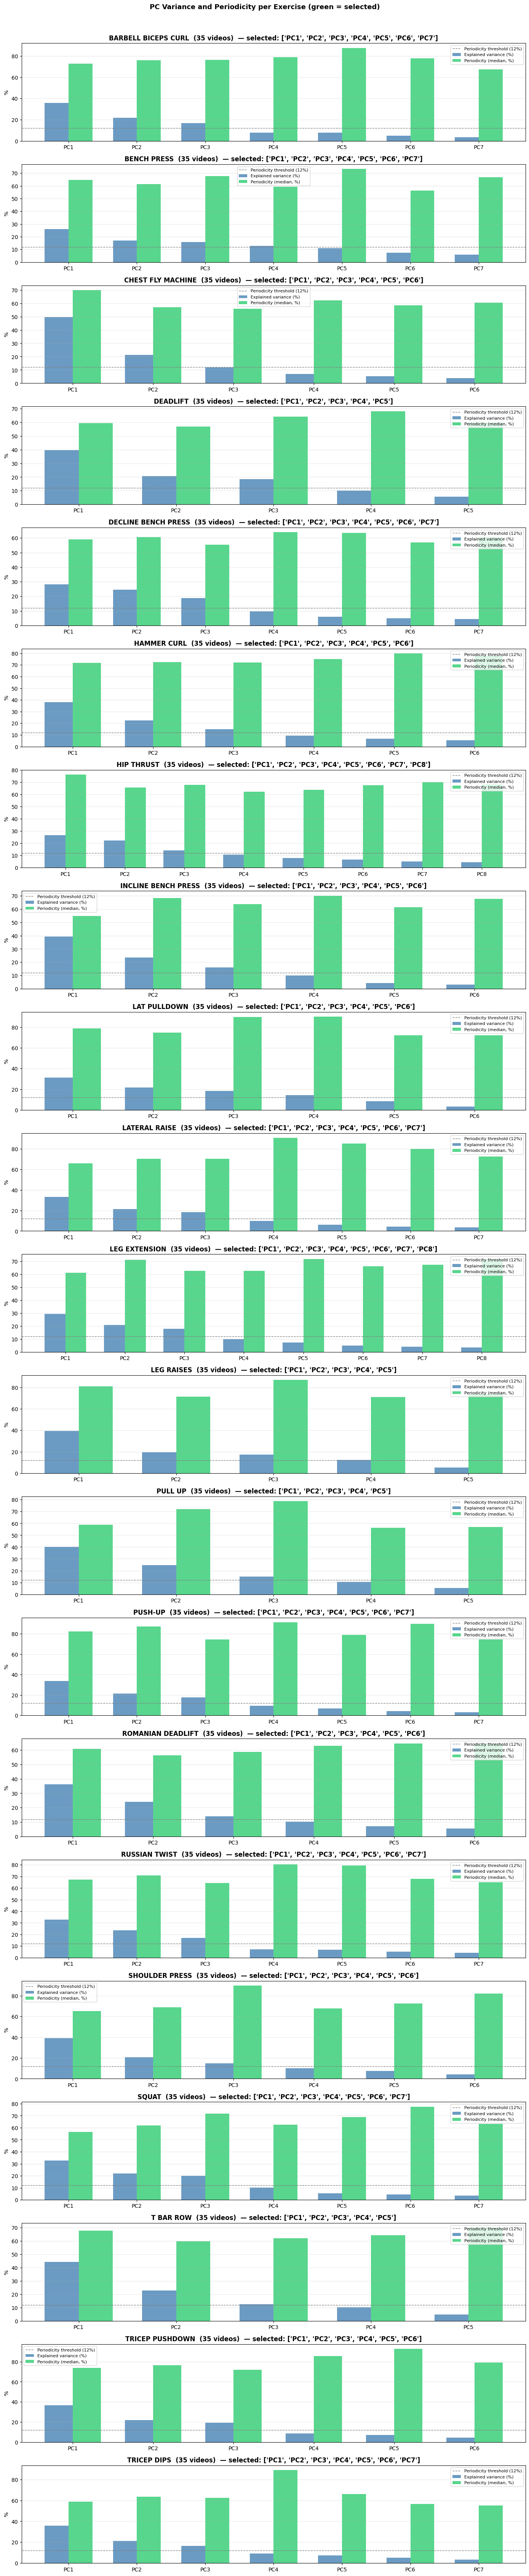

Saved -> pc_stats.png


In [ ]:
# PC variance + periodicity diagnostic
n_ex = len(exercise_profiles)
fig, axes = plt.subplots(n_ex, 1, figsize=(14, 3.2 * n_ex))
if n_ex == 1: axes = [axes]

for ax, (ex, prof) in zip(axes, exercise_profiles.items()):
    pc_indices = [s[0] + 1   for s in prof.pc_stats]
    variances  = [s[1] * 100 for s in prof.pc_stats]
    periods    = [s[2] * 100 for s in prof.pc_stats]
    bar_colors = ['#2ecc71' if s[0] in prof.selected_pcs else '#e74c3c' for s in prof.pc_stats]

    x, w = np.arange(len(pc_indices)), 0.35
    ax.bar(x - w/2, variances, w, label='Explained variance (%)', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, periods,   w, label='Periodicity (median, %)', color=bar_colors, alpha=0.8)
    ax.axhline(12, color='gray', linestyle='--', linewidth=1, label='Periodicity threshold (12%)')
    ax.set_xticks(x); ax.set_xticklabels([f'PC{i}' for i in pc_indices])
    ax.set_title(f"{ex.upper()}  ({prof.n_videos_used} videos)  "
                 f"— selected: {[f'PC{i+1}' for i in prof.selected_pcs]}", fontweight='bold')
    ax.set_ylabel('%'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("PC Variance and Periodicity per Exercise (green = selected)",
             fontsize=13, y=1.005, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pc_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> pc_stats.png")

## Method 1 — PCA rep counter

Projects each frame's 12-dim vector onto the selected PC, keeps a 60-frame rolling buffer,
SavGol-smooths (window ≤ 21), skips when the normalised range < 0.10 (amplitude guard), and
triggers an adaptive mean±0.8σ Schmitt. Identical to the original `PCARepCounter`.

In [ ]:
class PCARepCounter:
    def __init__(self, profile: ExerciseProfile):
        self.profile       = profile
        self._warmup       = deque(maxlen=60)
        self._in_valley    = True
        self._in_peak      = False
        self.rep_count     = 0
        self.current_value = 0.5

    def _project(self, landmarks):
        feat_dict, _ = extract_features_from_landmarks(landmarks)
        vec       = _get_feature_vec(feat_dict)              # (12,)
        scaled    = self.profile.scaler.transform([vec])
        projected = self.profile.pca.transform(scaled)[0]
        return projected[self.profile.selected_pcs]

    def update(self, landmarks):
        proj = self._project(landmarks)
        self._warmup.append(float(proj[0]))

        if len(self._warmup) >= 10:
            arr    = np.array(self._warmup)
            lo, hi = arr.min(), arr.max()
            rng    = hi - lo + 1e-8

            if (hi - lo) < 0.10:                              # amplitude guard
                return self.current_value, self.rep_count

            norm_arr = (arr - lo) / rng

            n   = len(norm_arr)
            win = n if n % 2 == 1 else n - 1
            win = max(min(win, 21), 5)
            smooth = savgol_filter(norm_arr, win, 3) if n >= 5 else norm_arr
            val    = float(smooth[-1])
            self.current_value = val

            mu, sigma  = arr.mean(), arr.std()
            peak_thr   = float(np.clip((mu + 0.8 * sigma - lo) / rng, 0.55, 0.90))
            valley_thr = float(np.clip((mu - 0.8 * sigma - lo) / rng, 0.10, 0.45))

            if val < valley_thr:
                self._in_valley = True;  self._in_peak = False
            if val > peak_thr and self._in_valley and not self._in_peak:
                self.rep_count += 1
                self._in_peak   = True;  self._in_valley = False

        return self.current_value, self.rep_count


print("PCARepCounter ready")

PCARepCounter ready


## Method 2 — Angle-based rep counter (Python port of the Swift logic)

Faithful 1:1 port of `FeatureExtractor.countingAngle` (3D joint angle, left/right averaged) and
`RepCounter.update` (per-exercise two-state Schmitt machine, exact thresholds). The only addition
is the shoulder-abduction angle source for `lateral raise` / `chest fly machine`, whose up/down
logic already exists in `RepCounter.swift`. Exercises with no Swift definition (e.g. `russian twist`)
return `None`.

In [ ]:
def calculate_angle_3d(a, b, c):
    """Angle in degrees at b formed by vectors b->a and b->c (3D), matching Swift FeatureExtractor.angle."""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc  = a - b, c - b
    n_ba, n_bc = np.linalg.norm(ba), np.linalg.norm(bc)
    if n_ba == 0 or n_bc == 0:
        return 0.0
    cosine = np.clip(np.dot(ba, bc) / (n_ba * n_bc), -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))


# Exercise -> which averaged angle drives counting (mirrors FeatureExtractor.countingAngle)
_ELBOW_EX = {
    "barbell biceps curl", "hammer curl", "push-up",
    "bench press", "incline bench press", "decline bench press",
    "tricep Pushdown", "tricep dips", "shoulder press",
    "lat pulldown", "pull Up", "t bar row",
}
_KNEE_EX     = {"squat", "leg extension"}
_HIP_EX      = {"deadlift", "romanian deadlift", "hip thrust", "leg raises"}
_SHOULDER_EX = {"lateral raise", "chest fly machine"}   # extension: shoulder-abduction angle
SUPPORTED_ANGLE_EXERCISES = _ELBOW_EX | _KNEE_EX | _HIP_EX | _SHOULDER_EX


def counting_angle(lms, exercise):
    """Port of FeatureExtractor.countingAngle. Returns the averaged driving angle, or None."""
    if len(lms) < 33:
        return None

    def P(i):
        return [lms[i].x, lms[i].y, lms[i].z]

    left_elbow  = calculate_angle_3d(P(11), P(13), P(15))
    right_elbow = calculate_angle_3d(P(12), P(14), P(16))
    left_knee   = calculate_angle_3d(P(23), P(25), P(27))
    right_knee  = calculate_angle_3d(P(24), P(26), P(28))
    left_hip    = calculate_angle_3d(P(11), P(23), P(25))
    right_hip   = calculate_angle_3d(P(12), P(24), P(26))
    left_shldr  = calculate_angle_3d(P(13), P(11), P(23))   # elbow-shoulder-hip
    right_shldr = calculate_angle_3d(P(14), P(12), P(24))

    if exercise in _ELBOW_EX:
        return (left_elbow + right_elbow) / 2
    if exercise in _KNEE_EX:
        return (left_knee + right_knee) / 2
    if exercise in _HIP_EX:
        return (left_hip + right_hip) / 2
    if exercise in _SHOULDER_EX:
        return (left_shldr + right_shldr) / 2
    return None


class AngleRepCounter:
    """Port of RepCounter.swift — per-exercise two-state Schmitt machine."""
    def __init__(self, exercise):
        self.exercise = exercise
        self.state    = "start"
        self.count    = 0

    def update(self, angle):
        ex = self.exercise

        if ex in ("barbell biceps curl", "hammer curl"):
            if angle > 150: self.state = "down"
            if self.state == "down" and angle < 70:
                self.count += 1; self.state = "up"

        elif ex == "push-up":
            if angle > 125: self.state = "top"
            if self.state == "top" and angle < 90:
                self.count += 1; self.state = "bottom"

        elif ex == "squat":
            if angle > 160: self.state = "top"
            if self.state == "top" and angle < 100:
                self.count += 1; self.state = "bottom"

        elif ex in ("bench press", "incline bench press", "decline bench press"):
            if angle > 150: self.state = "top"
            if self.state == "top" and angle < 100:
                self.count += 1; self.state = "bottom"

        elif ex == "leg extension":
            if angle < 100: self.state = "bent"
            if self.state == "bent" and angle > 155:
                self.count += 1; self.state = "extended"

        elif ex in ("lat pulldown", "pull Up", "t bar row"):
            if angle > 150: self.state = "open"
            if self.state == "open" and angle < 90:
                self.count += 1; self.state = "closed"

        elif ex in ("tricep Pushdown", "tricep dips"):
            if angle < 100: self.state = "bent"
            if self.state == "bent" and angle > 155:
                self.count += 1; self.state = "extended"

        elif ex == "shoulder press":
            if angle < 100: self.state = "bent"
            if self.state == "bent" and angle > 150:
                self.count += 1; self.state = "extended"

        elif ex in ("deadlift", "romanian deadlift", "hip thrust"):
            if angle < 120: self.state = "folded"
            if self.state == "folded" and angle > 165:
                self.count += 1; self.state = "extended"

        elif ex == "leg raises":
            if angle > 160: self.state = "down"
            if self.state == "down" and angle < 100:
                self.count += 1; self.state = "up"

        elif ex in ("lateral raise", "chest fly machine"):
            if angle < 40: self.state = "down"
            if self.state == "down" and angle > 85:
                self.count += 1; self.state = "up"

        return self.count

    def reset(self):
        self.count = 0
        self.state = "start"


print("AngleRepCounter + counting_angle ready (faithful Swift port)")
print(f"Angle method supports {len(SUPPORTED_ANGLE_EXERCISES)} exercises; "
      f"unsupported in dataset: {sorted(set(exercises) - SUPPORTED_ANGLE_EXERCISES)}")

AngleRepCounter + counting_angle ready (faithful Swift port)
Angle method supports 20 exercises; unsupported in dataset: ['russian twist']


## CoreML export bundle

Per-exercise `metadata.json` + `weights.json` (scaler + PCA), zipped and downloaded — same as the
original PCA notebook, minus the removed DTW fields (`template`, `dtw_enter`, `dtw_exit`, …).

In [ ]:
import shutil
from google.colab import files

PCA_DIR = f'{OUTPUT_DIR}/pca_bundle'
os.makedirs(PCA_DIR, exist_ok=True)

for exercise_name, prof in exercise_profiles.items():
    ex_dir = Path(PCA_DIR) / exercise_name
    ex_dir.mkdir(exist_ok=True)

    n_features = prof.scaler.mean_.shape[0]   # 12

    metadata = {
        "exercise":           exercise_name,
        "feature_dim":        n_features,
        "feature_names":      SYM_ANGLE_NAMES + [f"norm_y_lm{i}" for i in Y_LANDMARK_INDICES],
        "y_landmark_indices": Y_LANDMARK_INDICES,
        "bilateral_pairs":    [[l, r] for l, r in BILATERAL_PAIRS],
        "unilateral":         UNILATERAL,
        "selected_pcs":       prof.selected_pcs,
        "fps":                prof.fps,
        "n_videos_used":      prof.n_videos_used,
        "schmitt_k":          0.8,
        "schmitt_peak_min":   0.55,
        "schmitt_peak_max":   0.90,
        "schmitt_valley_min": 0.10,
        "schmitt_valley_max": 0.45,
        "min_amplitude":      0.10,
        "warmup_frames":      60,
        "savgol_window":      21,
        "savgol_poly":        3,
    }
    with open(ex_dir / "metadata.json", "w") as fh:
        json.dump(metadata, fh, indent=2)

    weights = {
        "scaler_mean":              prof.scaler.mean_.tolist(),
        "scaler_scale":             prof.scaler.scale_.tolist(),
        "pca_components":           prof.pca.components_.tolist(),
        "pca_mean":                 prof.pca.mean_.tolist(),
        "explained_variance_ratio": prof.pca.explained_variance_ratio_.tolist(),
        "n_components":             int(prof.pca.n_components_),
    }
    with open(ex_dir / "weights.json", "w") as fh:
        json.dump(weights, fh, indent=2)

    print(f"  {exercise_name}: metadata.json + weights.json saved")

zip_path = f'{OUTPUT_DIR}/pca_bundle'
shutil.make_archive(zip_path, 'zip', PCA_DIR)
files.download(f'{zip_path}.zip')
print("\nDownload triggered — check your browser downloads")

  barbell biceps curl: metadata.json + weights.json saved
  bench press: metadata.json + weights.json saved
  chest fly machine: metadata.json + weights.json saved
  deadlift: metadata.json + weights.json saved
  decline bench press: metadata.json + weights.json saved
  hammer curl: metadata.json + weights.json saved
  hip thrust: metadata.json + weights.json saved
  incline bench press: metadata.json + weights.json saved
  lat pulldown: metadata.json + weights.json saved
  lateral raise: metadata.json + weights.json saved
  leg extension: metadata.json + weights.json saved
  leg raises: metadata.json + weights.json saved
  pull Up: metadata.json + weights.json saved
  push-up: metadata.json + weights.json saved
  romanian deadlift: metadata.json + weights.json saved
  russian twist: metadata.json + weights.json saved
  shoulder press: metadata.json + weights.json saved
  squat: metadata.json + weights.json saved
  t bar row: metadata.json + weights.json saved
  tricep Pushdown: metada

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download triggered — check your browser downloads


In [21]:
def load_profiles_from_zip():
    """
    Upload a downloaded coreml_bundle.zip, extract it, and rebuild
    exercise_profiles so the eval loop works after a kernel disconnect.

    Usage (run instead of the profile-building cell):
        exercise_profiles = load_profiles_from_zip()
    """
    from google.colab import files as colab_files
    import zipfile, shutil

    print("Select your coreml_bundle.zip to upload...")
    uploaded = colab_files.upload()
    if not uploaded:
        print("No file uploaded."); return {}

    zip_path    = list(uploaded.keys())[0]
    extract_dir = Path("/tmp/coreml_bundle_loaded")

    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir()

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    # handle both flat (exercise dirs at root) and one-level-nested zips
    ex_dirs = [p for p in extract_dir.iterdir()
               if p.is_dir() and (p / "metadata.json").exists()]
    if not ex_dirs:
        for sub in extract_dir.iterdir():
            if sub.is_dir():
                ex_dirs = [p for p in sub.iterdir()
                           if p.is_dir() and (p / "metadata.json").exists()]
                if ex_dirs: break

    if not ex_dirs:
        print("No exercise directories found in zip."); return {}

    profiles = {}
    for ex_dir in sorted(ex_dirs):
        meta = json.load(open(ex_dir / "metadata.json"))
        w    = json.load(open(ex_dir / "weights.json"))

        scaler = StandardScaler()
        scaler.mean_          = np.array(w["scaler_mean"],  dtype=np.float64)
        scaler.scale_         = np.array(w["scaler_scale"], dtype=np.float64)
        scaler.var_           = scaler.scale_ ** 2
        scaler.n_features_in_ = scaler.mean_.shape[0]

        pca = PCA(n_components=int(w["n_components"]))
        pca.components_               = np.array(w["pca_components"],           dtype=np.float64)
        pca.mean_                     = np.array(w["pca_mean"],                 dtype=np.float64)
        pca.explained_variance_ratio_ = np.array(w["explained_variance_ratio"], dtype=np.float64)
        pca.n_components_             = int(w["n_components"])
        pca.n_features_in_            = pca.components_.shape[1]

        profiles[ex_dir.name] = ExerciseProfile(
            name=ex_dir.name,
            angle_names=SYM_ANGLE_NAMES,
            scaler=scaler, pca=pca,
            selected_pcs=list(meta["selected_pcs"]),
            pc_stats=[],
            fps=float(meta.get("fps", 30.0)),
            n_videos_used=int(meta.get("n_videos_used", 0)),
        )

    print(f"Loaded {len(profiles)} profiles: {sorted(profiles.keys())}")
    return profiles


print("load_profiles_from_zip ready")

load_profiles_from_zip ready


In [22]:
exercise_profiles = load_profiles_from_zip()

Select your coreml_bundle.zip to upload...


Saving coreml_bundle.zip to coreml_bundle.zip
Loaded 22 profiles: ['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'plank', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep Pushdown', 'tricep dips']


In [27]:
for prof in exercise_profiles.values():
    prof.pca.explained_variance_ = (
        prof.pca.explained_variance_ratio_ * prof.pca.n_features_in_
    )


## Test-set evaluation — manual rep entry

For every test video (plank already excluded): run MediaPipe once, drive **both** counters from the
same landmarks, show the **raw clip**, print both predicted counts, then type the true reps.
Results are appended to `test_eval_results.csv` after each entry, so a kernel restart resumes where
you left off (already-scored videos are skipped). Enter a number, `s` to skip, or `q` to stop.

In [28]:
EVAL_MAX_FRAMES = 1200   # raise if some test clips are longer than ~40s @30fps

def run_counts_on_video(video_path, exercise, max_frames=EVAL_MAX_FRAMES):
    """Single MediaPipe pass; returns (pca_pred, angle_pred). angle_pred is None if unsupported."""
    prof          = exercise_profiles.get(exercise)
    pca_counter   = PCARepCounter(prof) if prof is not None else None
    supported     = exercise in SUPPORTED_ANGLE_EXERCISES
    angle_counter = AngleRepCounter(exercise) if supported else None

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    vid_opts = mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=mp_vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    fi = 0
    with mp_vision.PoseLandmarker.create_from_options(vid_opts) as det:
        while fi < max_frames:
            ret, frame = cap.read()
            if not ret: break
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ts  = int(fi * 1000 / fps)
            img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            res = det.detect_for_video(img, ts)
            if res.pose_landmarks:
                lms = res.pose_landmarks[0]
                if pca_counter is not None:
                    pca_counter.update(lms)
                if angle_counter is not None:
                    ang = counting_angle(lms, exercise)
                    if ang is not None:
                        angle_counter.update(ang)
            fi += 1
    cap.release()

    pca_pred   = pca_counter.rep_count if pca_counter is not None else None
    angle_pred = angle_counter.count   if angle_counter is not None else None
    return pca_pred, angle_pred


def display_test_video(path, width=700):
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    ipy_display(HTML(
        f'<video width="{width}" controls autoplay loop muted>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>'
    ))


print("Evaluation helpers ready")

Evaluation helpers ready


In [29]:
exercise_profiles

{'barbell biceps curl': ExerciseProfile(name='barbell biceps curl', angle_names=['avg_elbow', 'avg_shoulder', 'avg_hip', 'avg_knee', 'avg_ankle', 'torso'], scaler=StandardScaler(), pca=PCA(n_components=8), selected_pcs=[0, 1, 2, 3, 4, 5], pc_stats=[], fps=30.22648382115946, n_videos_used=24),
 'bench press': ExerciseProfile(name='bench press', angle_names=['avg_elbow', 'avg_shoulder', 'avg_hip', 'avg_knee', 'avg_ankle', 'torso'], scaler=StandardScaler(), pca=PCA(n_components=8), selected_pcs=[0, 1, 2, 3, 4, 5, 6], pc_stats=[], fps=24.0, n_videos_used=23),
 'chest fly machine': ExerciseProfile(name='chest fly machine', angle_names=['avg_elbow', 'avg_shoulder', 'avg_hip', 'avg_knee', 'avg_ankle', 'torso'], scaler=StandardScaler(), pca=PCA(n_components=8), selected_pcs=[0, 1, 2, 3, 4, 5], pc_stats=[], fps=30.200568662107127, n_videos_used=25),
 'deadlift': ExerciseProfile(name='deadlift', angle_names=['avg_elbow', 'avg_shoulder', 'avg_hip', 'avg_knee', 'avg_ankle', 'torso'], scaler=Standa

In [ ]:
import time

CSV_PATH = f"{OUTPUT_DIR}/eval_results.csv"
COLS = ["filepath", "filename", "exercise", "pca_pred", "angle_pred", "true_reps"]

if os.path.exists(CSV_PATH):
    results_df = pd.read_csv(CSV_PATH)
    done = set(results_df["filepath"].astype(str))
    print(f"Resuming — {len(done)} videos already scored.")
else:
    results_df = pd.DataFrame(columns=COLS)
    done = set()

test_items = [(ex, vp) for ex in sorted(test_videos) for vp in test_videos[ex]]
N = len(test_items)
print(f"Test videos to evaluate: {N}")

for idx, (ex, vp) in enumerate(test_items, 1):
    if vp in done:
        continue

    pca_pred, angle_pred = run_counts_on_video(vp, ex)

    clear_output(wait=True)
    print(f"[{idx}/{N}]  {ex}  —  {Path(vp).name}")
    display_test_video(vp)

    angle_str = "N/A (unsupported)" if angle_pred is None else angle_pred
    print(f"\n  PCA   predicted reps: {pca_pred}")
    print(f"  Angle predicted reps: {angle_str}")

    time.sleep(2)   # let the browser decode + render the video before the prompt appears

    resp = input("  TRUE reps (number) | 's' skip | 'q' quit: ").strip().lower()
    if resp == "q":
        print("Stopping — progress saved.")
        break
    if resp == "s":
        continue
    try:
        true_reps = int(resp)
    except ValueError:
        print("  Not a number — skipping.")
        continue

    row = {"filepath": vp, "filename": Path(vp).name, "exercise": ex,
           "pca_pred": pca_pred, "angle_pred": angle_pred, "true_reps": true_reps}
    results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)
    results_df.to_csv(CSV_PATH, index=False)
    done.add(vp)

print(f"\nResults saved -> {CSV_PATH}  ({len(results_df)} videos scored)")

## Results — MAE / RMSE comparison

Loads the CSV and compares the two methods. The angle method's `russian twist` rows are `NaN`
(unsupported) and are excluded from its metrics only.

Overall (lower MAE/RMSE is better):


,n,MAE,RMSE,bias,exact_%,within1_%
PCA,56.0,2.411,3.921,2.304,44.643,50.00
Angle,54.0,3.944,5.852,-2.167,14.815,29.63



Per-exercise MAE:


/tmp/ipykernel_2146/2183074451.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_ex = res.groupby("exercise").apply(lambda g: pd.Series({


,n,PCA_MAE,Angle_MAE
exercise,,,
barbell biceps curl,2.0,7.000,4.000
bench press,3.0,1.667,1.667
chest fly machine,4.0,4.000,3.500
deadlift,2.0,3.500,2.500
decline bench press,3.0,3.667,3.000
hammer curl,3.0,0.000,6.333
hip thrust,3.0,3.000,2.333
incline bench press,3.0,5.667,9.000
lat pulldown,3.0,1.000,2.000


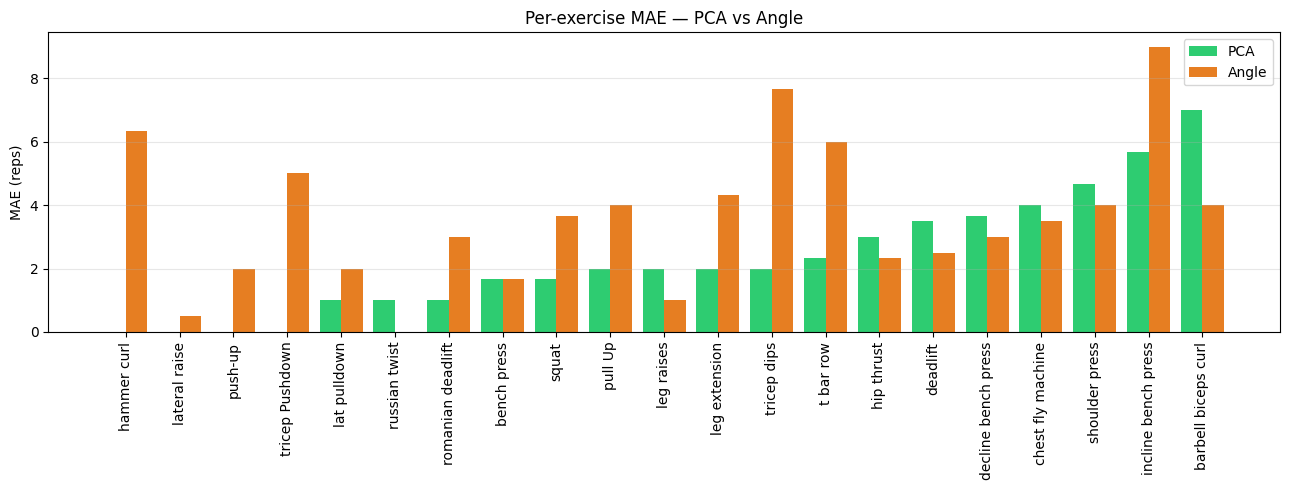

In [32]:
res = pd.read_csv(CSV_PATH)
if len(res) == 0:
    print("No results yet — run the evaluation loop above.")
else:
    res["pca_err"]   = res["pca_pred"]   - res["true_reps"]
    res["angle_err"] = res["angle_pred"] - res["true_reps"]

    def metrics(err):
        err = err.dropna()
        if len(err) == 0:
            return dict(n=0, MAE=np.nan, RMSE=np.nan, bias=np.nan, exact=np.nan, within1=np.nan)
        return dict(
            n=len(err),
            MAE=err.abs().mean(),
            RMSE=float(np.sqrt((err ** 2).mean())),
            bias=err.mean(),
            exact=(err == 0).mean() * 100,
            within1=(err.abs() <= 1).mean() * 100,
        )

    summary = pd.DataFrame({
        "PCA":   metrics(res["pca_err"]),
        "Angle": metrics(res["angle_err"]),
    }).T
    summary = summary[["n", "MAE", "RMSE", "bias", "exact", "within1"]]
    summary = summary.rename(columns={"exact": "exact_%", "within1": "within1_%"})
    print("Overall (lower MAE/RMSE is better):")
    display(summary.round(3))

    # Per-exercise MAE
    per_ex = res.groupby("exercise").apply(lambda g: pd.Series({
        "n":         len(g),
        "PCA_MAE":   g["pca_err"].abs().mean(),
        "Angle_MAE": g["angle_err"].abs().mean(),
    })).round(3)
    print("\nPer-exercise MAE:")
    display(per_ex)

    # Plot per-exercise MAE
    pe = per_ex.sort_values("PCA_MAE")
    x = np.arange(len(pe)); w = 0.4
    plt.figure(figsize=(13, 5))
    plt.bar(x - w/2, pe["PCA_MAE"],   w, label="PCA",   color="#2ecc71")
    plt.bar(x + w/2, pe["Angle_MAE"], w, label="Angle", color="#e67e22")
    plt.xticks(x, pe.index, rotation=90)
    plt.ylabel("MAE (reps)"); plt.title("Per-exercise MAE — PCA vs Angle")
    plt.legend(); plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/mae_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()